# 1. Import Library

In [297]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline

from lightgbm import LGBMClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split
)

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

warnings.filterwarnings("ignore")

# 2. Load Dataset

In [298]:
uploaded = files.upload()

df = pd.read_csv("car_insurance_fraud_dataset.csv", sep=";")

print(f"Data shape: {df.shape}")

Saving car_insurance_fraud_dataset.csv to car_insurance_fraud_dataset.csv
Data shape: (30000, 24)


# 3. Exploratory Data Analysis

## 3.1 Head of Data

In [299]:
print('Head of Data:')
display(df.head())

Head of Data:


,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,IN,1000,1150.80,38,Female,College,Office Staff,Reading,13/06/2024,...,IN,Charlesville,4,2,0,2,YES,20752.94,24084.36,N
1,POL100001,PA,1500,1038.97,41,Male,College,Retired,Cooking,23/03/2025,...,PA,Joshuaberg,7,1,0,0,NO,3768.11,4129.82,Y
2,POL100002,NY,1000,1252.74,36,Female,Master's,Unemployed,Movies,26/01/2025,...,NY,Reynoldsfurt,8,1,0,0,YES,12774.94,14977.00,Y
3,POL100003,NY,1000,1164.97,26,Male,PhD,Technician,Reading,03/06/2024,...,NY,Josephchester,10,4,3,0,YES,18935.07,21346.28,N
4,POL100004,IL,2000,1240.61,38,Female,Associate,Sales,Camping,21/05/2024,...,IL,Caitlinfort,8,1,0,2,YES,35181.37,39313.85,N


## 3.2 Dataset Information

In [300]:
print("Dataset Information:")
df.info(verbose=True)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 


## 3.3 Statistical Summary

In [301]:
print('Statistical Summary:')
display(df.describe())

Statistical Summary:


,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,1075.516667,1224.460490,40.581867,13.902167,1.717200,0.653500,1.771600,12956.753688,14898.069484
std,582.727254,198.905424,10.867583,5.415284,0.866439,0.914658,1.337346,11817.428588,13597.580911
min,250.000000,400.000000,18.000000,0.000000,1.000000,0.000000,0.000000,841.030000,977.770000
25%,500.000000,1089.307500,33.000000,10.000000,1.000000,0.000000,1.000000,3448.137500,3966.645000
50%,1000.000000,1224.095000,41.000000,15.000000,2.000000,0.000000,2.000000,9165.165000,10544.180000
75%,1500.000000,1358.575000,48.000000,18.000000,2.000000,1.000000,3.000000,18929.885000,21762.705000
max,2500.000000,2051.750000,80.000000,23.000000,5.000000,4.000000,5.000000,93884.760000,109232.370000


## 3.4 Unique Values Each Column

In [302]:
print('Unique Values:')
print(df.nunique().to_string())

Unique Values:
policy_id                      30000
policy_state                       8
policy_deductible                  8
policy_annual_premium          24503
insured_age                       63
insured_sex                        2
insured_education_level            7
insured_occupation                16
insured_hobbies                   12
incident_date                    731
incident_type                      4
collision_type                     4
incident_severity                  3
authorities_contacted              5
incident_state                    21
incident_city                  17931
incident_hour_of_the_day          24
number_of_vehicles_involved        5
bodily_injuries                    5
witnesses                          6
police_report_available            2
claim_amount                   29751
total_claim_amount             29744
fraud_reported                     2


## 3.5 Missing Values Check

In [303]:
print("Missing Values:")
print(df.isnull().sum().to_string())

Missing Values:
policy_id                      0
policy_state                   0
policy_deductible              0
policy_annual_premium          0
insured_age                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
bodily_injuries                0
witnesses                      0
police_report_available        0
claim_amount                   0
total_claim_amount             0
fraud_reported                 0


## 3.6 Duplicate Check

In [304]:
duplicates = df[df.duplicated()]
print(f'Jumlah duplikat di data: {len(duplicates)}')

Jumlah duplikat di data: 0


## 3.7 Target Distribution (Imbalance Check)

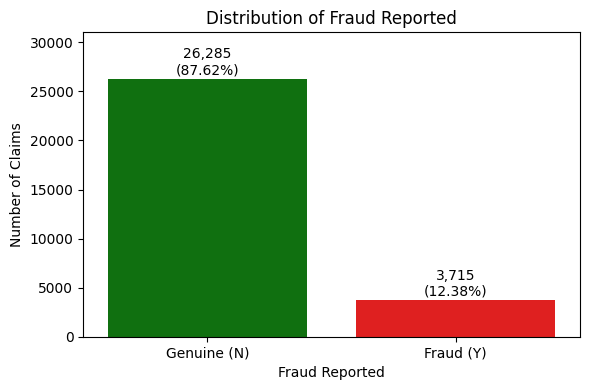

In [305]:
target_count = df["fraud_reported"].value_counts().reindex(["N", "Y"])
target_percent = (
    df["fraud_reported"]
    .value_counts(normalize=True)
    .reindex(["N", "Y"]) * 100
)

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df,
    x="fraud_reported",
    order=["N", "Y"],
    hue="fraud_reported",
    hue_order=["N", "Y"],
    palette={"N": "green", "Y": "red"},
    legend=False,
    ax=ax
)

ax.set_ylim(0, target_count.max() * 1.18)

for bar, count, pct in zip(ax.patches, target_count, target_percent):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + target_count.max() * 0.005,
        f"{count:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_xticklabels(["Genuine (N)", "Fraud (Y)"])
ax.set_xlabel("Fraud Reported")
ax.set_ylabel("Number of Claims")
ax.set_title("Distribution of Fraud Reported", fontsize=12)

plt.tight_layout()
plt.show()

## 3.8 Continuous Numerical Features Distribution

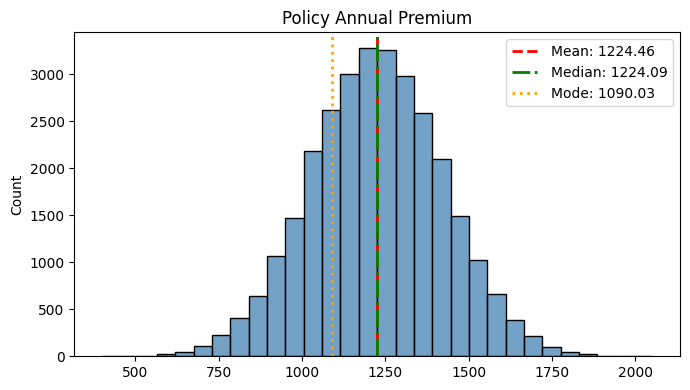

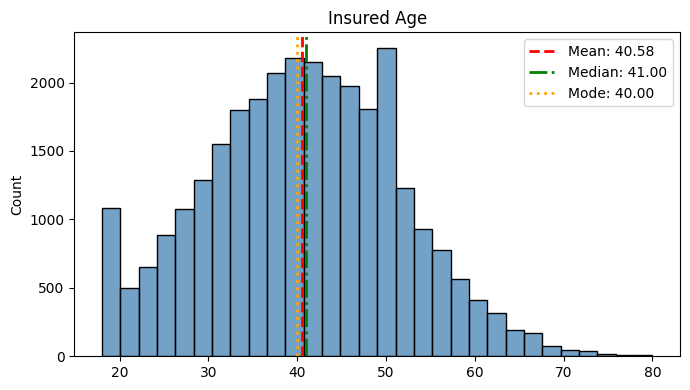

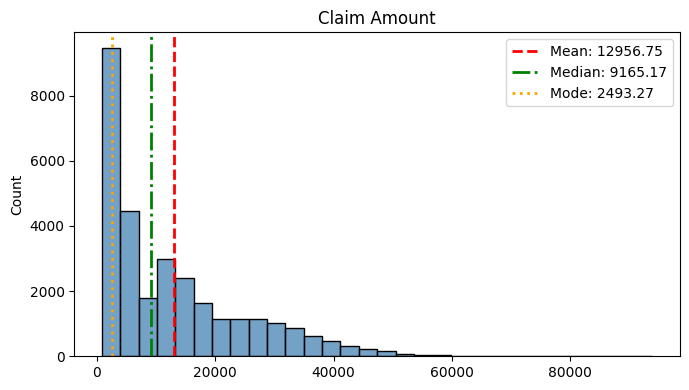

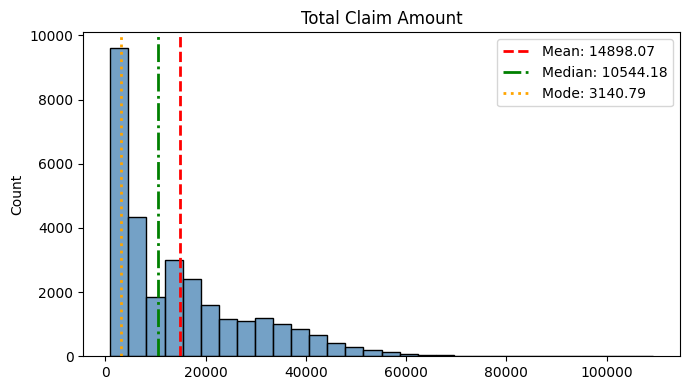

In [306]:
continuous_features = [
    "policy_annual_premium",
    "insured_age",
    "claim_amount",
    "total_claim_amount"
]

for feature in continuous_features:

    mean = df[feature].mean()
    median = df[feature].median()
    mode = df[feature].mode()[0]

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        color="steelblue"
    )

    plt.axvline(
        mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean:.2f}"
    )

    plt.axvline(
        median,
        color="green",
        linestyle="-.",
        linewidth=2,
        label=f"Median: {median:.2f}"
    )

    plt.axvline(
        mode,
        color="orange",
        linestyle=":",
        linewidth=2,
        label=f"Mode: {mode:.2f}"
    )

    plt.title(feature.replace("_", " ").title())
    plt.xlabel("")
    plt.ylabel("Count")
    plt.legend()

    plt.tight_layout()
    plt.show()

## 3.9 Discrete Numerical Features

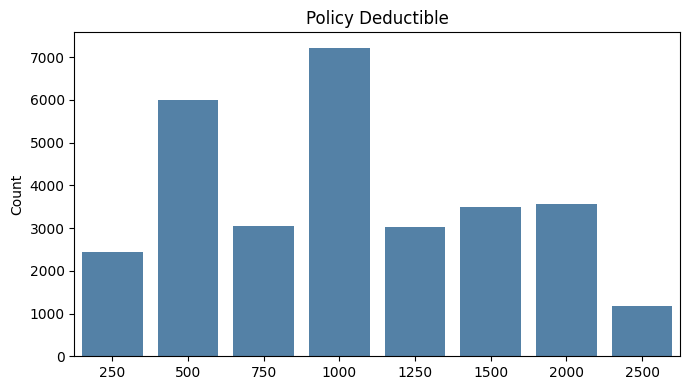

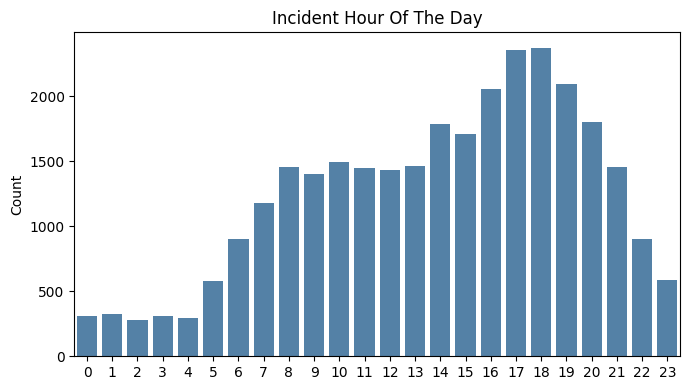

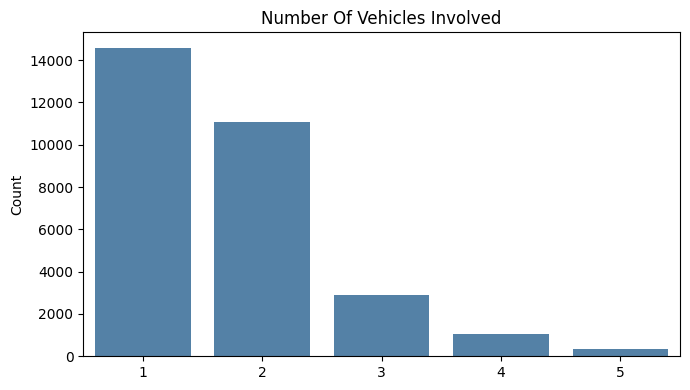

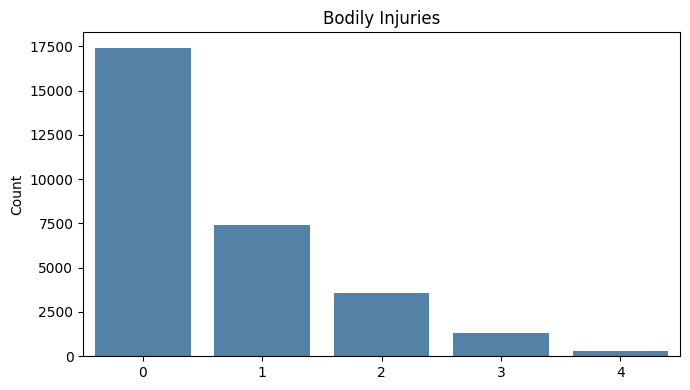

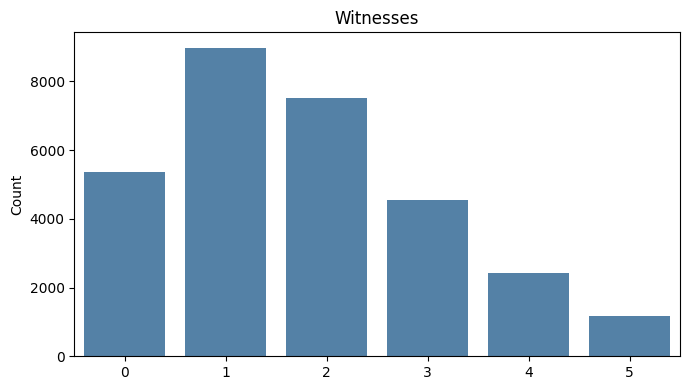

In [307]:
discrete_features = [
    "policy_deductible",
    "incident_hour_of_the_day",
    "number_of_vehicles_involved",
    "bodily_injuries",
    "witnesses"
]

for feature in discrete_features:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=feature,
        color="steelblue"
    )

    plt.title(feature.replace("_", " ").title())
    plt.xlabel("")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

## 3.10 Categorical Features Distribution

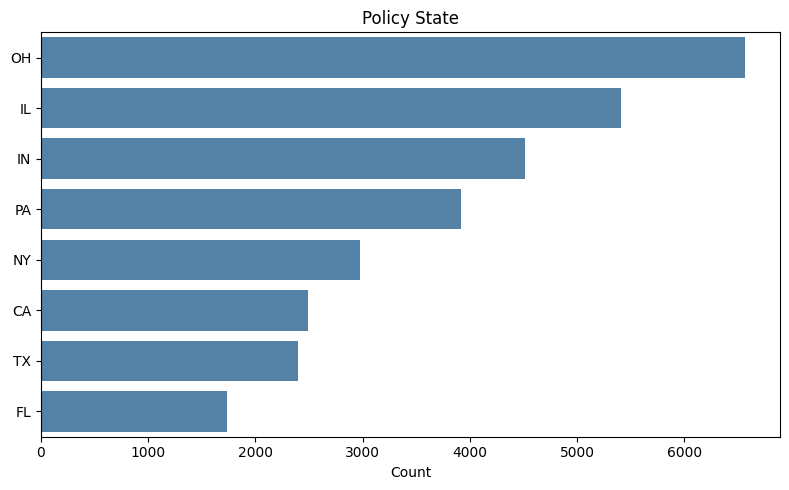

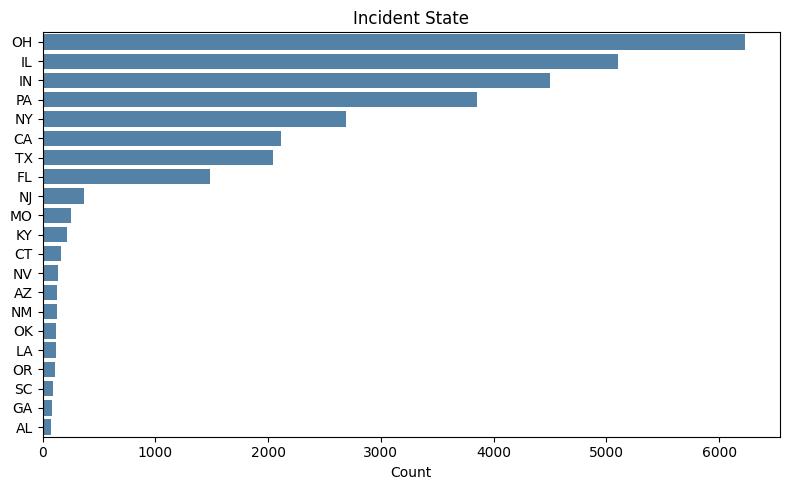

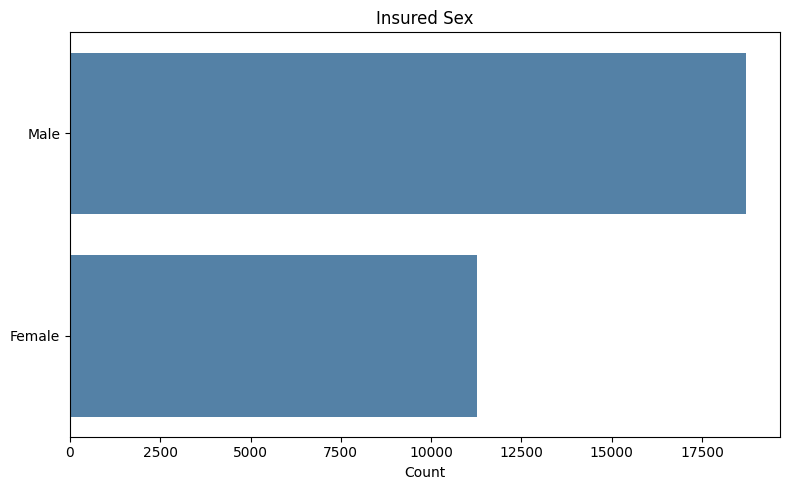

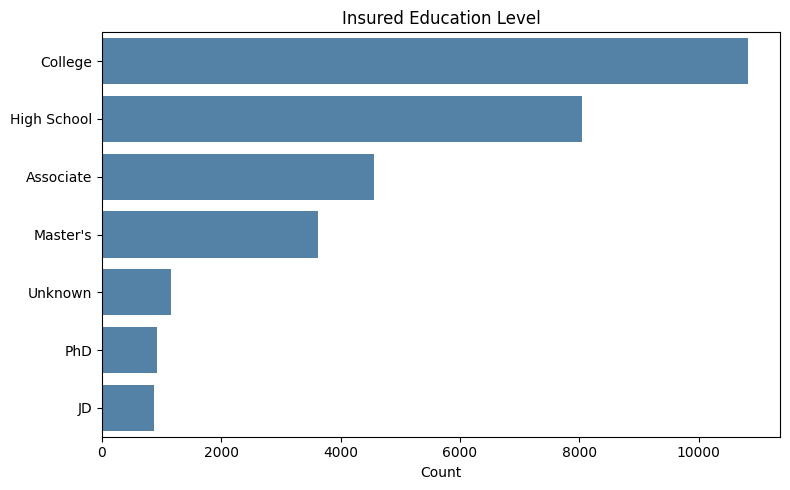

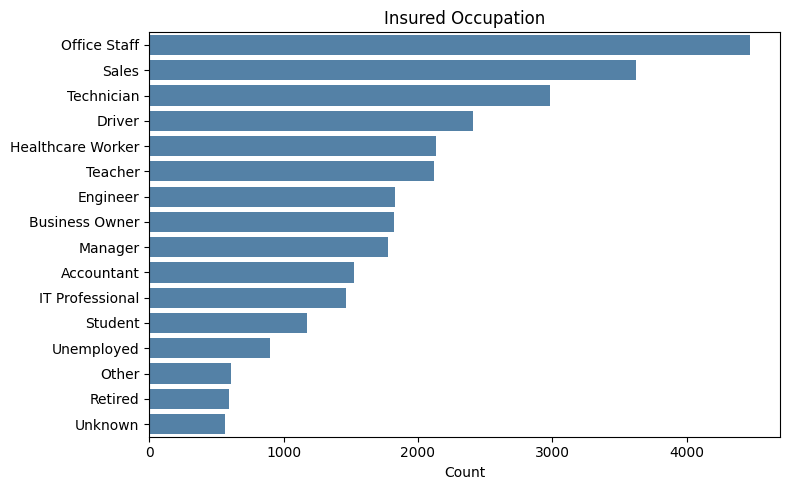

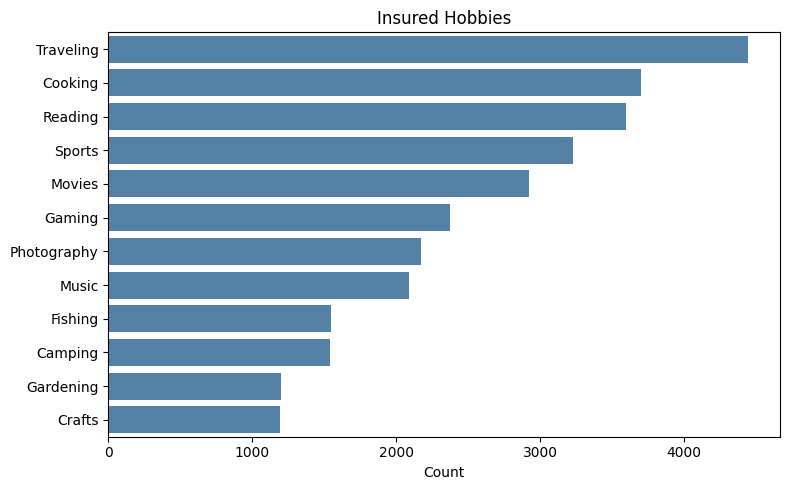

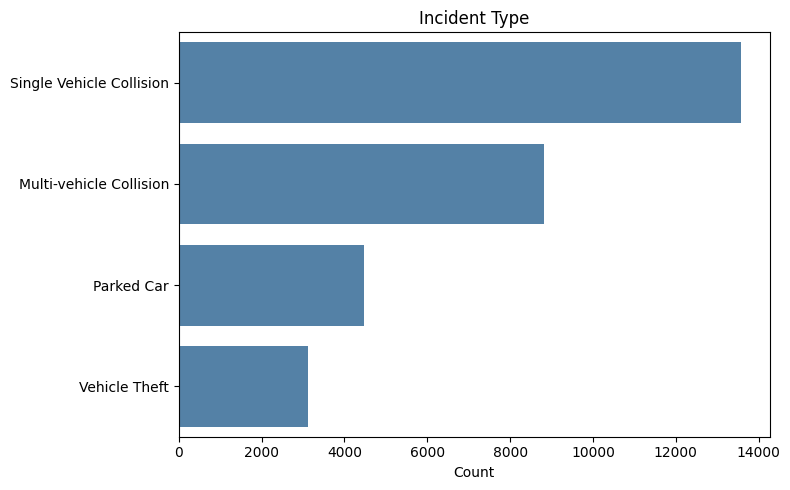

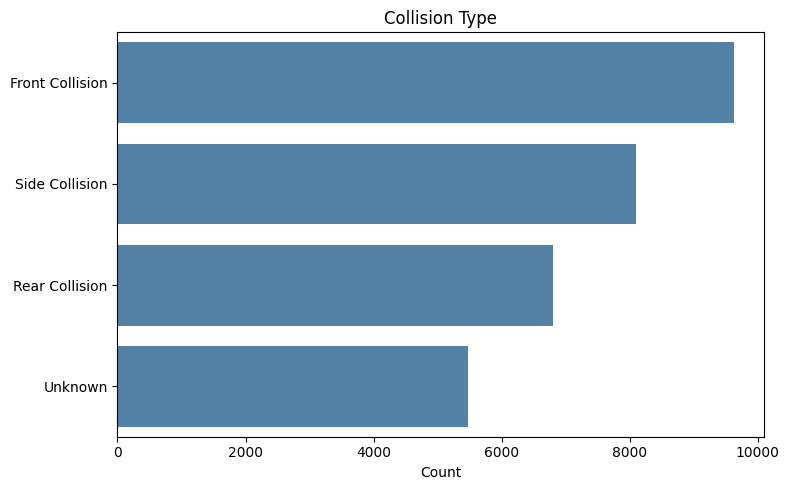

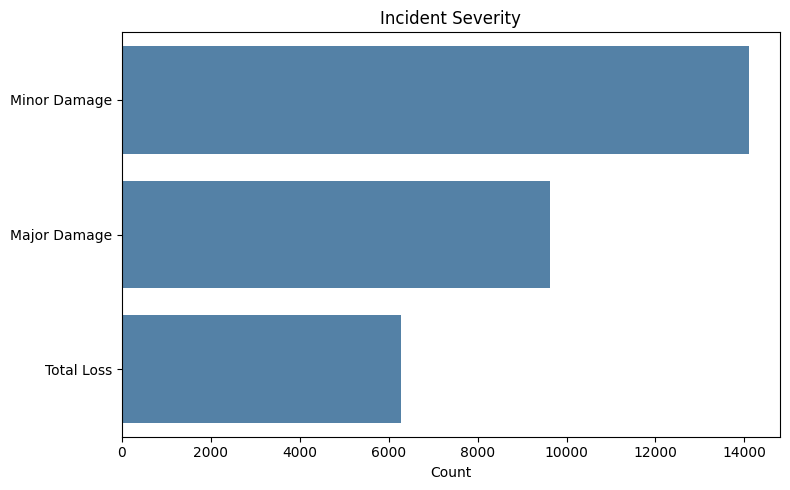

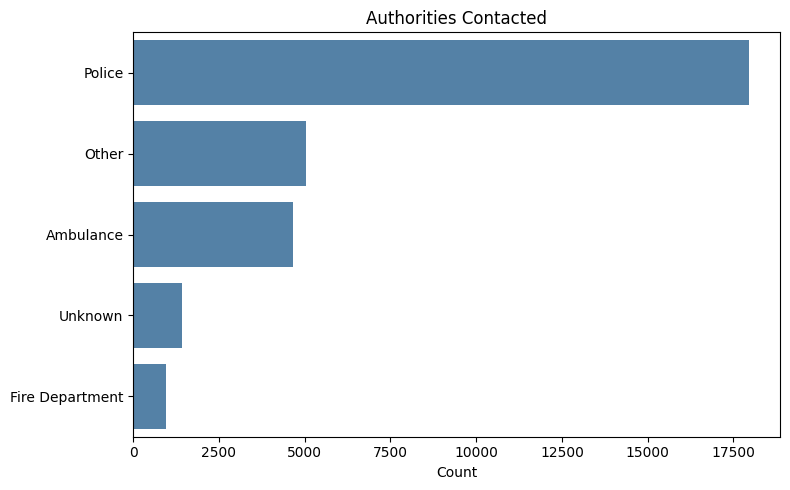

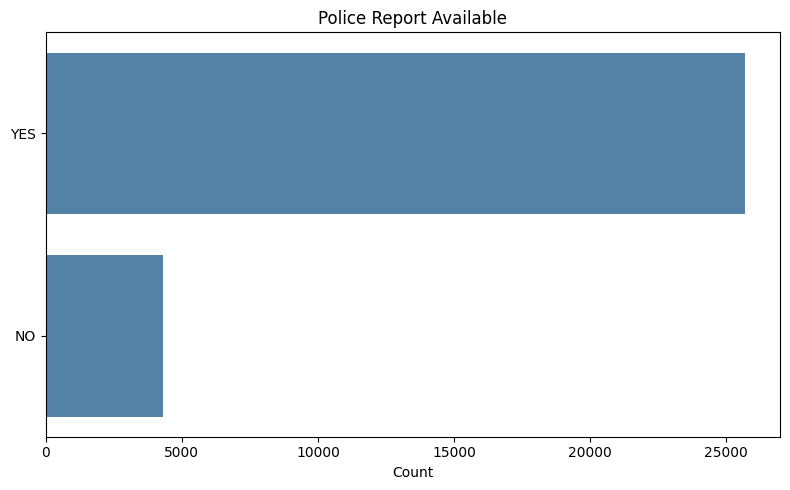

In [308]:
categorical_features = [
    "policy_state",
    "incident_state",
    "insured_sex",
    "insured_education_level",
    "insured_occupation",
    "insured_hobbies",
    "incident_type",
    "collision_type",
    "incident_severity",
    "authorities_contacted",
    "police_report_available"
]

for feature in categorical_features:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        y=feature,
        order=df[feature].value_counts(dropna=False).index,
        color="steelblue"
    )

    plt.title(feature.replace("_", " ").title())
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()

    plt.show()

## 3.11 Numerical Features vs Fraud Status

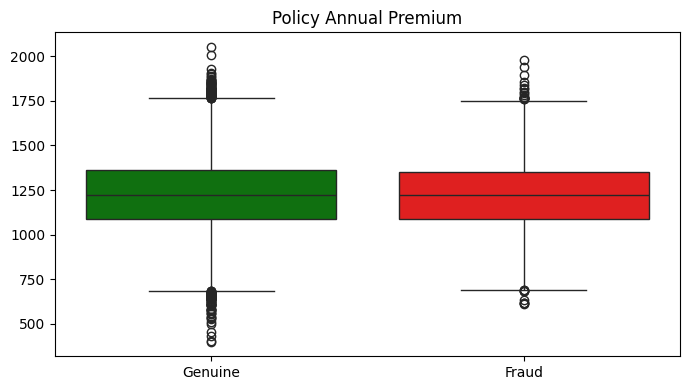

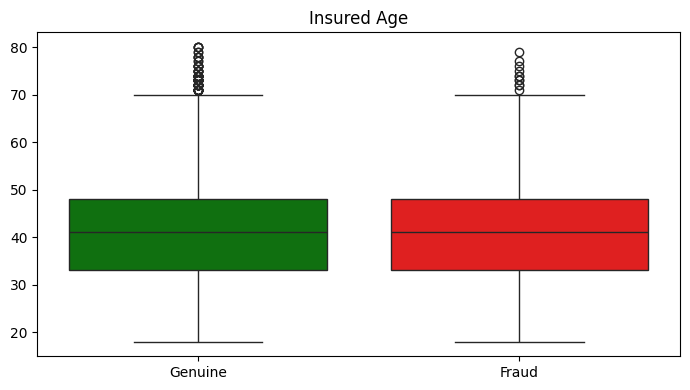

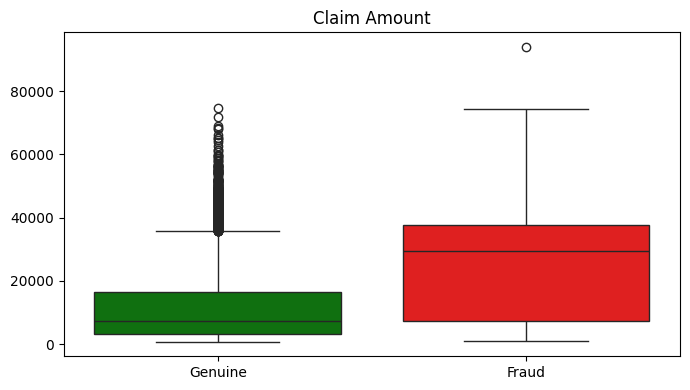

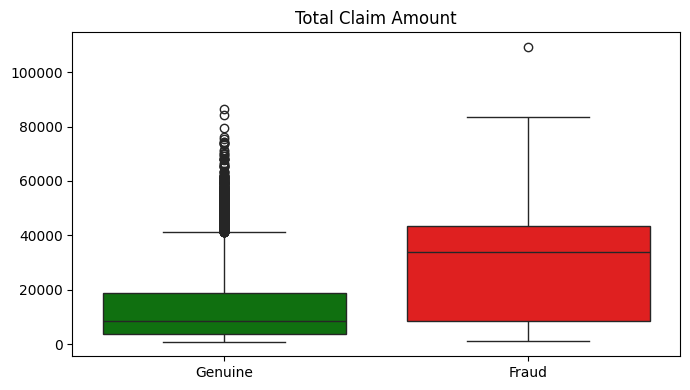

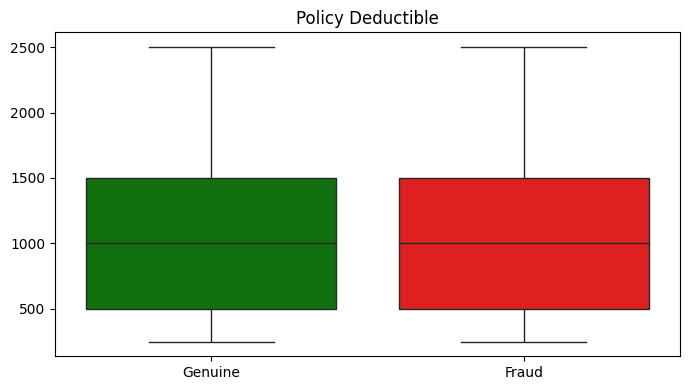

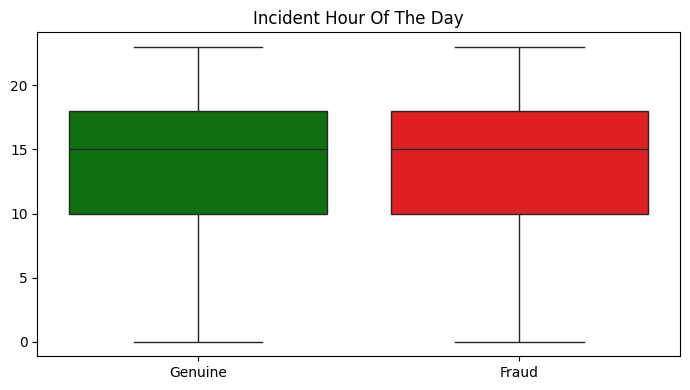

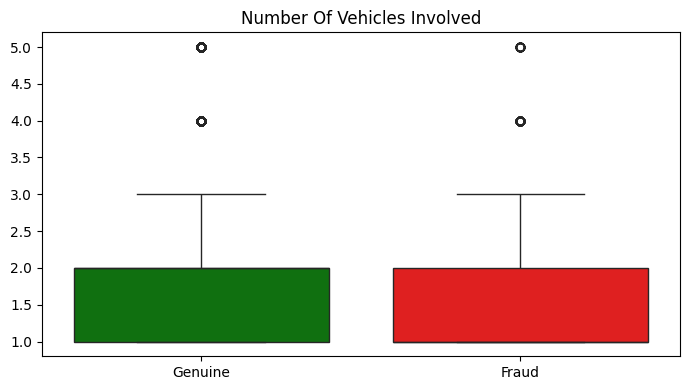

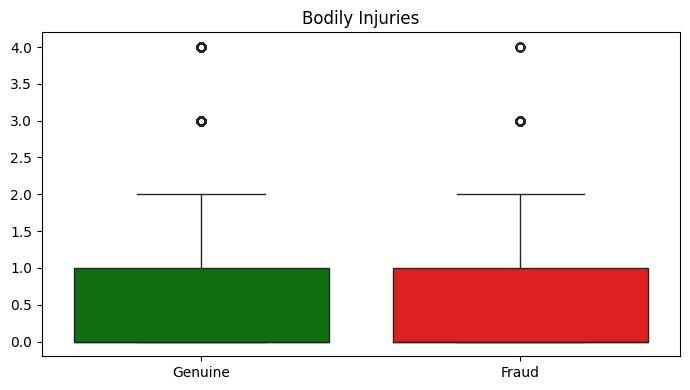

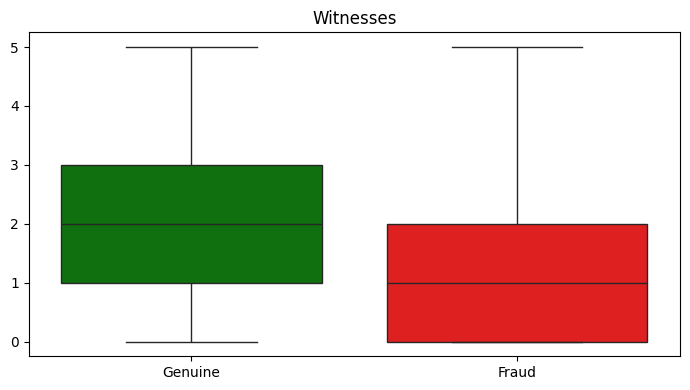

In [309]:
numerical_features = continuous_features + discrete_features

for feature in numerical_features:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x="fraud_reported",
        y=feature,
        order=["N", "Y"],
        palette=["green", "red"]
    )

    plt.xticks(
        [0, 1],
        ["Genuine", "Fraud"]
    )

    plt.title(feature.replace("_", " ").title())
    plt.xlabel("")
    plt.ylabel("")

    plt.tight_layout()
    plt.show()

## 3.12 Categorical Features vs Fraud Status

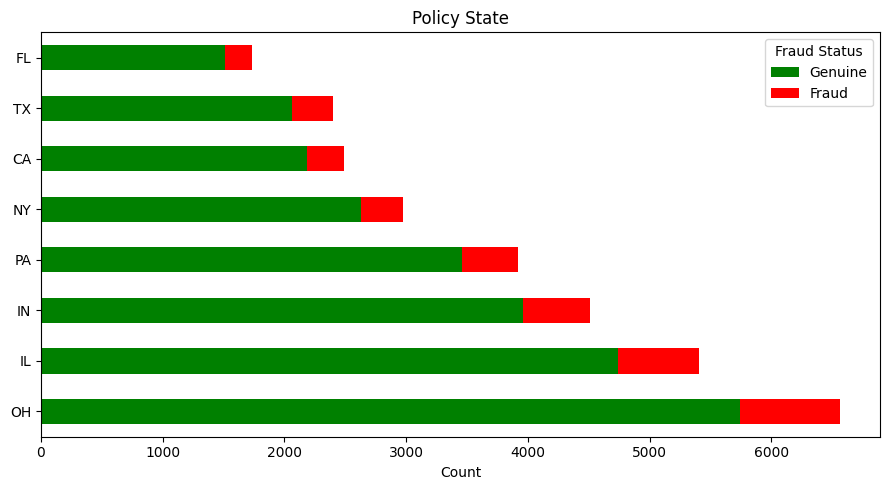

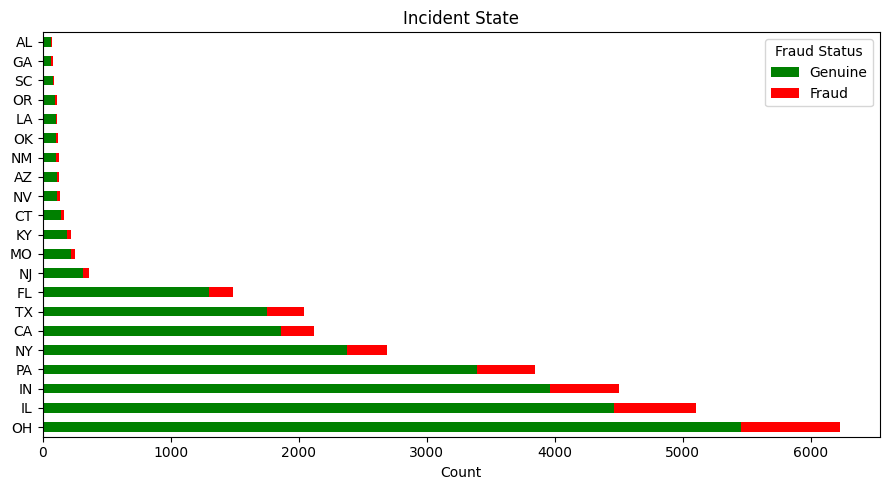

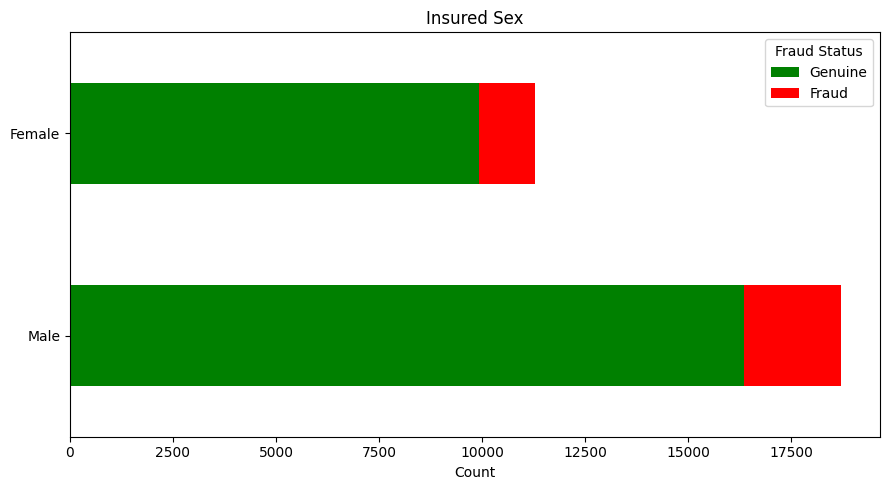

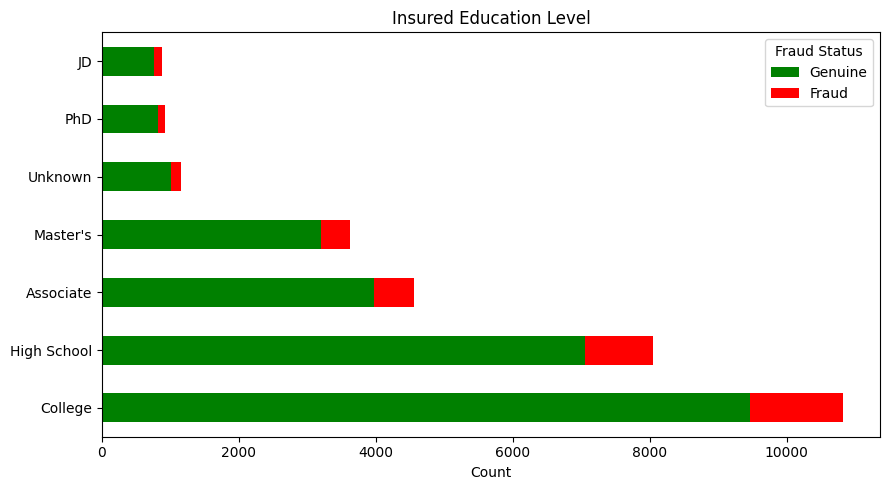

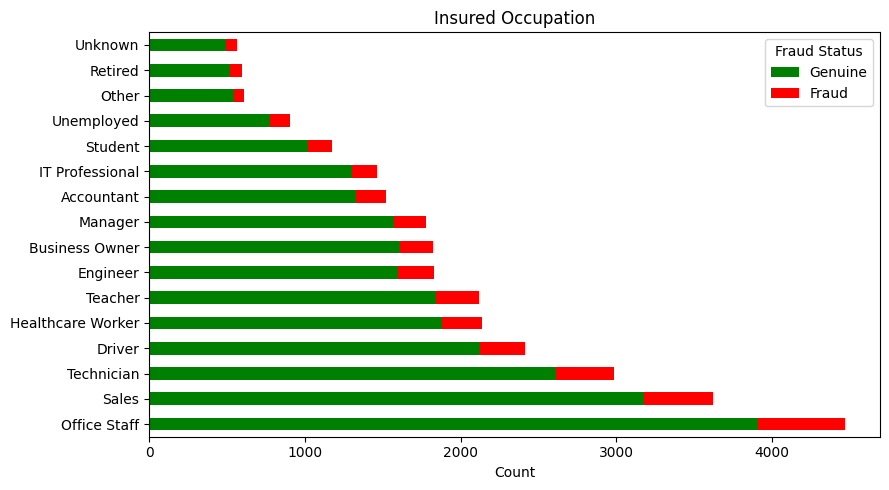

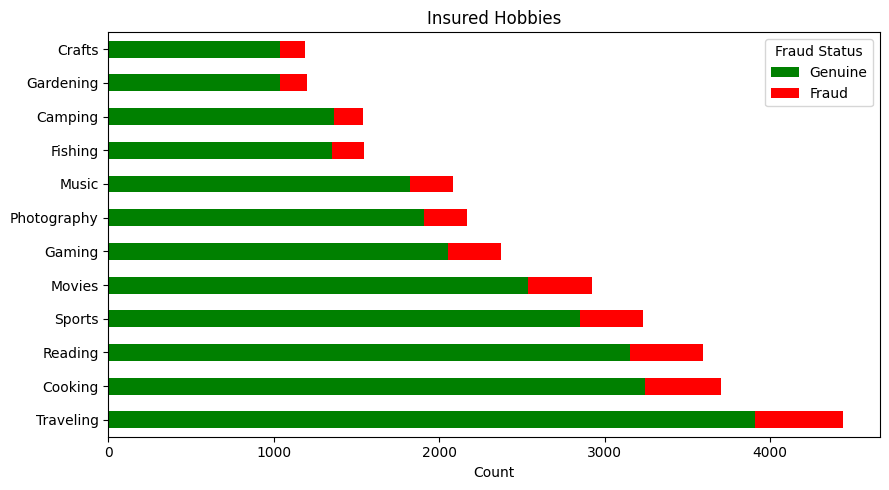

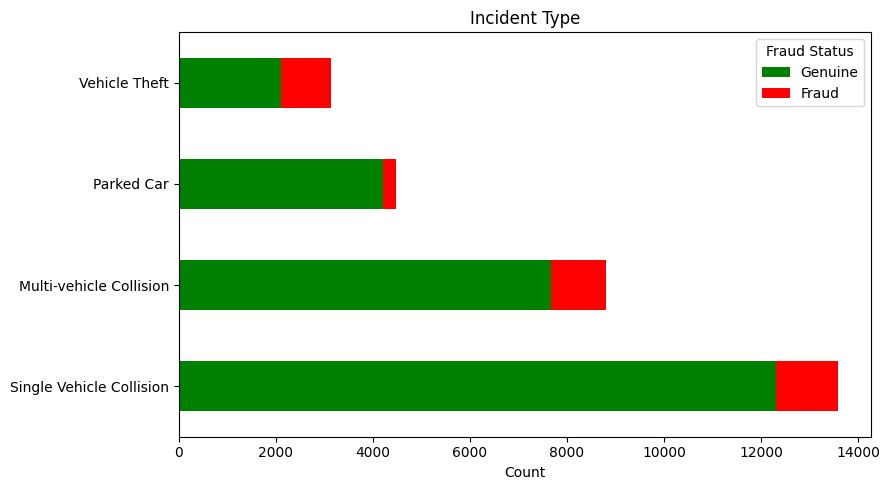

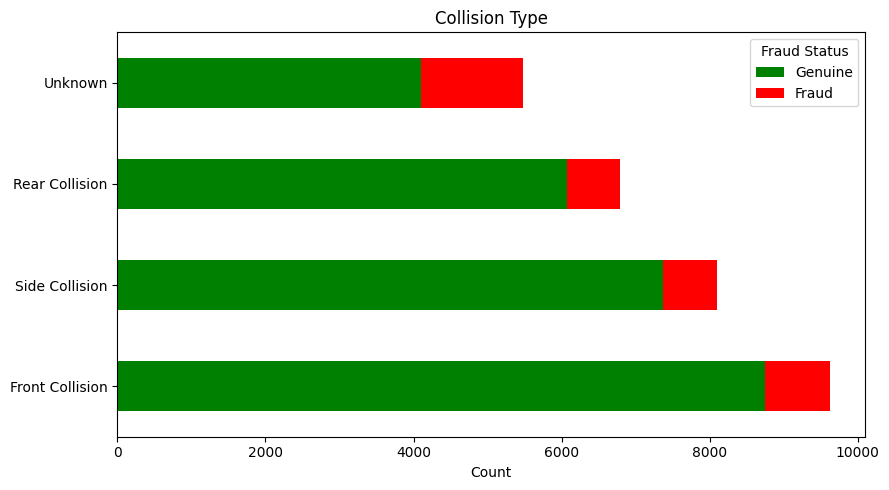

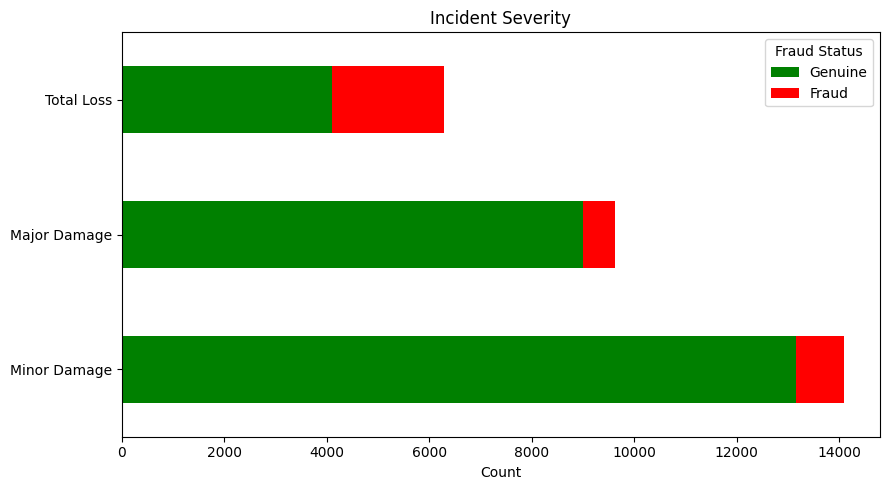

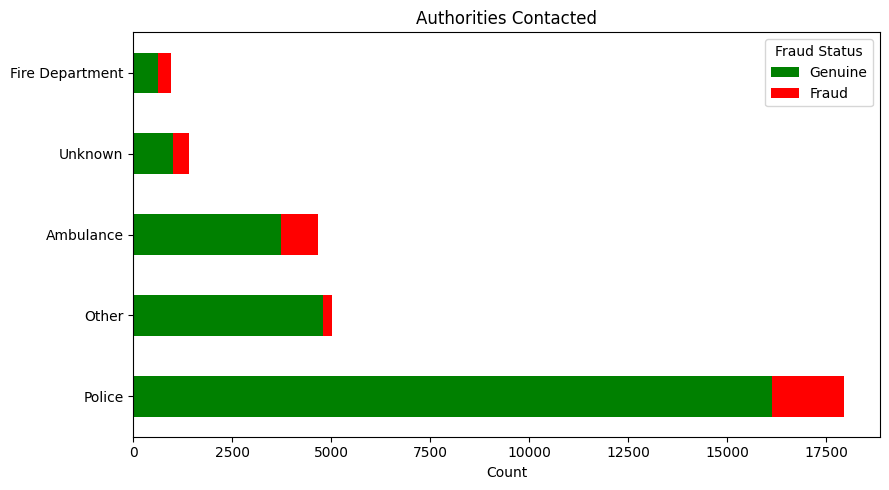

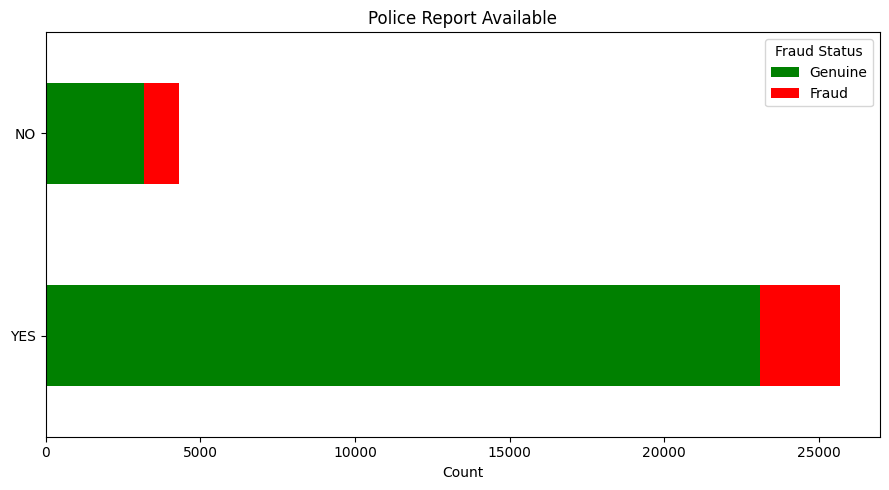

In [310]:
categorical_features = [
    "policy_state",
    "incident_state",
    "insured_sex",
    "insured_education_level",
    "insured_occupation",
    "insured_hobbies",
    "incident_type",
    "collision_type",
    "incident_severity",
    "authorities_contacted",
    "police_report_available"
]

for feature in categorical_features:

    ct = pd.crosstab(
        df[feature],
        df["fraud_reported"]
    )

    ct = ct.loc[df[feature].value_counts().index]

    ct = ct.rename(columns={
        "N": "Genuine",
        "Y": "Fraud"
    })

    ct.plot(
        kind="barh",
        stacked=True,
        figsize=(9, 5),
        color=["green", "red"]
    )

    plt.title(feature.replace("_", " ").title())
    plt.xlabel("Count")
    plt.ylabel("")
    plt.legend(title="Fraud Status")

    plt.tight_layout()
    plt.show()

## 3.13 Correlation Analysis

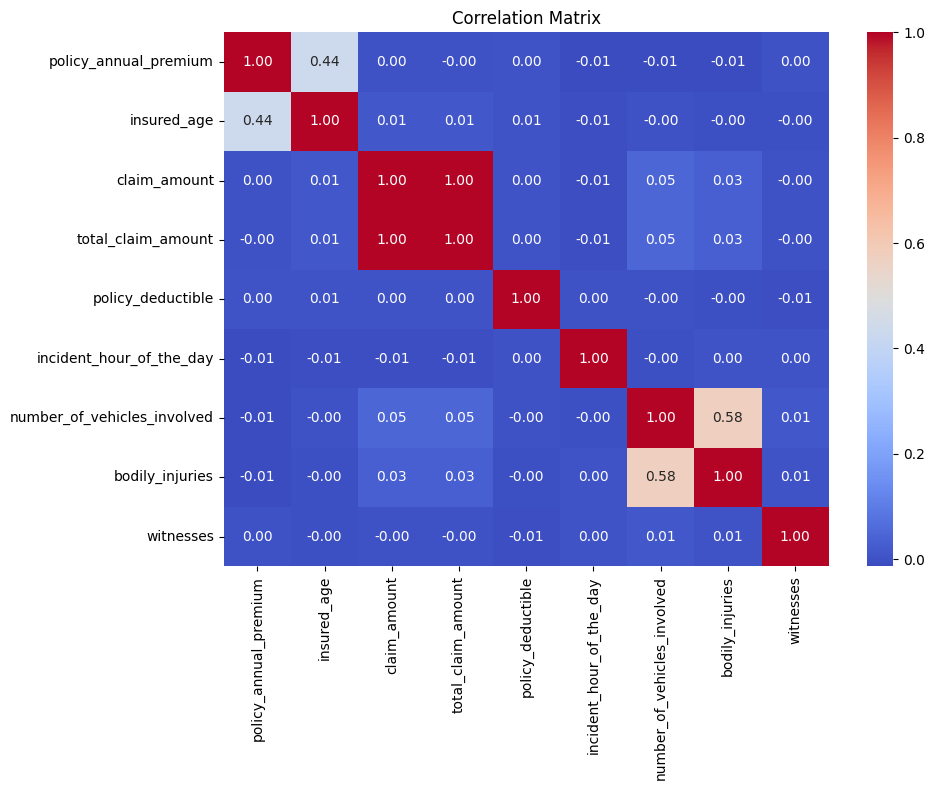

In [311]:
plt.figure(figsize=(10,8))

corr = df[numerical_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# 4. Data Preprocessing

## 4.1 Feature Selection

In [312]:
drop_columns = [
    "policy_id",
    "incident_date",
    "incident_city"
]

df = df.drop(columns=drop_columns)

print(f"Dataset Shape : {df.shape}")
display(df.head())

Dataset Shape : (30000, 21)


,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,...,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,IN,1000,1150.80,38,Female,College,Office Staff,Reading,Multi-vehicle Collision,Front Collision,...,Police,IN,4,2,0,2,YES,20752.94,24084.36,N
1,PA,1500,1038.97,41,Male,College,Retired,Cooking,Single Vehicle Collision,Front Collision,...,Unknown,PA,7,1,0,0,NO,3768.11,4129.82,Y
2,NY,1000,1252.74,36,Female,Master's,Unemployed,Movies,Vehicle Theft,Unknown,...,Police,NY,8,1,0,0,YES,12774.94,14977.00,Y
3,NY,1000,1164.97,26,Male,PhD,Technician,Reading,Multi-vehicle Collision,Rear Collision,...,Police,NY,10,4,3,0,YES,18935.07,21346.28,N
4,IL,2000,1240.61,38,Female,Associate,Sales,Camping,Single Vehicle Collision,Unknown,...,Ambulance,IL,8,1,0,2,YES,35181.37,39313.85,N


## 4.2 Define Features and Target

In [313]:
X = df.drop(columns="fraud_reported")
y = df["fraud_reported"]

print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")

Features Shape : (30000, 20)
Target Shape   : (30000,)


## 4.3 Encode Target Variable

In [314]:
y = y.map({
    "N": 0,
    "Y": 1
})

display(
    pd.DataFrame({
        "Count": y.value_counts().sort_index(),
        "Percentage (%)": round(
            y.value_counts(normalize=True).sort_index() * 100,
            2
        )
    }).rename(index={
        0: "Genuine (0)",
        1: "Fraud (1)"
    })
)

,Count,Percentage (%)
fraud_reported,,
Genuine (0),26285,87.62
Fraud (1),3715,12.38


## 4.4 Train-Test Split

In [315]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (24000, 20)
X_test  : (6000, 20)
y_train : (24000,)
y_test  : (6000,)


In [316]:
split_summary = pd.DataFrame({
    "Train (%)": round(y_train.value_counts(normalize=True).sort_index() * 100, 2),
    "Test (%)": round(y_test.value_counts(normalize=True).sort_index() * 100, 2)
})

split_summary.index = ["Genuine (0)", "Fraud (1)"]

display(split_summary)

,Train (%),Test (%)
Genuine (0),87.62,87.62
Fraud (1),12.38,12.38


## 4.5 Categorical Encoding

### Ordinal Encoding

In [317]:
severity_order = [
    "Minor Damage",
    "Major Damage",
    "Total Loss"
]

ordinal_encoder = OrdinalEncoder(
    categories=[severity_order],
    dtype=np.int64
)

X_train["incident_severity"] = ordinal_encoder.fit_transform(
    X_train[["incident_severity"]]
).ravel()

X_test["incident_severity"] = ordinal_encoder.transform(
    X_test[["incident_severity"]]
).ravel()

### One-Hot Encoding

In [318]:
nominal_features = [
    "policy_state",
    "incident_state",
    "insured_sex",
    "insured_education_level",
    "insured_occupation",
    "insured_hobbies",
    "incident_type",
    "collision_type",
    "authorities_contacted",
    "police_report_available"
]

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

train_encoded = pd.DataFrame(
    onehot_encoder.fit_transform(X_train[nominal_features]),
    columns=onehot_encoder.get_feature_names_out(nominal_features),
    index=X_train.index
).astype(int)

test_encoded = pd.DataFrame(
    onehot_encoder.transform(X_test[nominal_features]),
    columns=onehot_encoder.get_feature_names_out(nominal_features),
    index=X_test.index
).astype(int)

X_train_encoded = pd.concat(
    [
        X_train.drop(columns=nominal_features),
        train_encoded
    ],
    axis=1
)

X_test_encoded = pd.concat(
    [
        X_test.drop(columns=nominal_features),
        test_encoded
    ],
    axis=1
)

In [319]:
print("Encoded Dataset")
print(f"X_train_encoded: {X_train_encoded.shape}")
print(f"X_test_encoded : {X_test_encoded.shape}")

print()

print("Scaled Dataset")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")

print()

print("Target")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

print()

print(f"Number of Features: {X_train_encoded.shape[1]}")

Encoded Dataset
X_train_encoded: (24000, 91)
X_test_encoded : (6000, 91)

Scaled Dataset
X_train_scaled: (24000, 91)
X_test_scaled : (6000, 91)

Target
y_train: (24000,)
y_test : (6000,)

Number of Features: 91


# 5. Baseline Modeling

## 5.1 Logistic Regression

### Model Training

In [320]:
logreg_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

logreg_pipeline.fit(
    X_train_encoded,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

### Prediction

In [321]:
logreg_pred = logreg_pipeline.predict(
    X_test_encoded
)

logreg_prob = logreg_pipeline.predict_proba(
    X_test_encoded
)[:, 1]

### Classification Report

In [322]:
print(
    classification_report(
        y_test,
        logreg_pred,
        target_names=["Non-Fraud", "Fraud"],
        digits=4
    )
)

              precision    recall  f1-score   support

   Non-Fraud     0.9069    0.9800    0.9420      5257
       Fraud     0.6708    0.2880    0.4030       743

    accuracy                         0.8943      6000
   macro avg     0.7889    0.6340    0.6725      6000
weighted avg     0.8777    0.8943    0.8753      6000



### Confusion Matrix

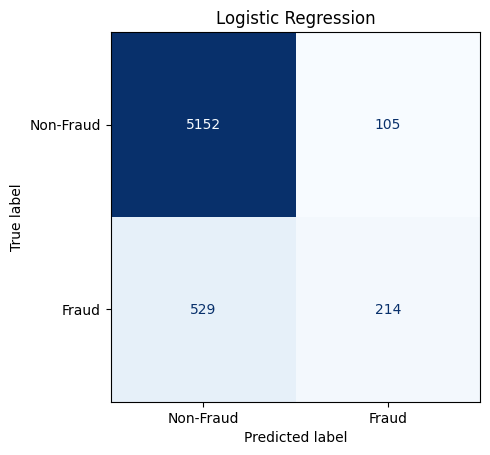

In [323]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logreg_pred,
    display_labels=["Non-Fraud", "Fraud"],
    cmap="Blues",
    colorbar=False
)

plt.title("Logistic Regression")

plt.show()

### ROC Curve

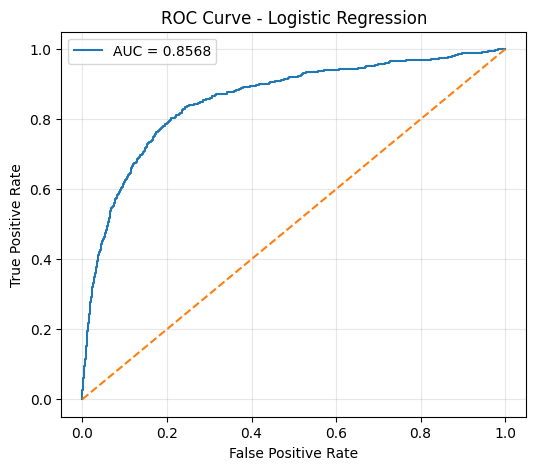

In [324]:
logreg_fpr, logreg_tpr, _ = roc_curve(
    y_test,
    logreg_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    logreg_fpr,
    logreg_tpr,
    label=f"AUC = {roc_auc_score(y_test, logreg_prob):.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Precision-Recall Curve

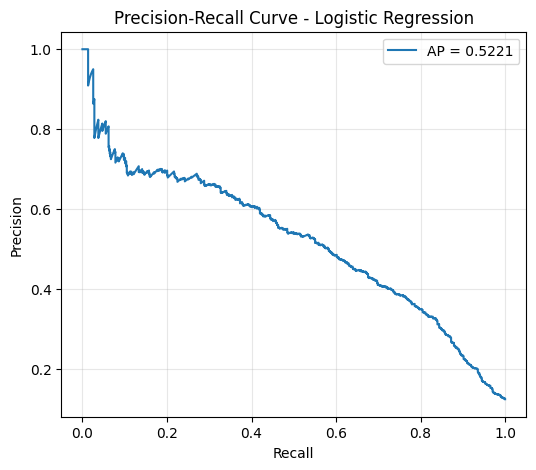

In [325]:
logreg_precision, logreg_recall, _ = precision_recall_curve(
    y_test,
    logreg_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    logreg_recall,
    logreg_precision,
    label=f"AP = {average_precision_score(y_test, logreg_prob):.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Logistic Regression")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## 5.2 LightGBM

### Model Training

In [336]:
lgbm = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

lgbm.fit(
    X_train_encoded,
    y_train
)

LGBMClassifier(random_state=42, verbosity=-1)

### Prediction

In [337]:
lgbm_pred = lgbm.predict(
    X_test_encoded
)

lgbm_prob = lgbm.predict_proba(
    X_test_encoded
)[:, 1]

### Classification Report

In [338]:
print(
    classification_report(
        y_test,
        lgbm_pred,
        target_names=["Non-Fraud", "Fraud"],
        digits=4
    )
)

              precision    recall  f1-score   support

   Non-Fraud     0.9233    0.9688    0.9455      5257
       Fraud     0.6612    0.4307    0.5216       743

    accuracy                         0.9022      6000
   macro avg     0.7922    0.6997    0.7336      6000
weighted avg     0.8909    0.9022    0.8930      6000



### Confusion Matrix

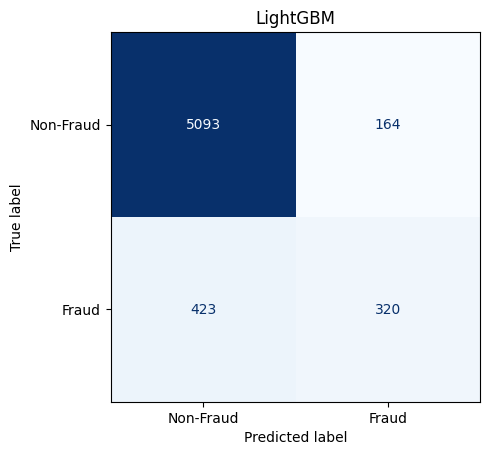

In [339]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lgbm_pred,
    display_labels=["Non-Fraud", "Fraud"],
    cmap="Blues",
    colorbar=False
)

plt.title("LightGBM")

plt.show()

### ROC Curve

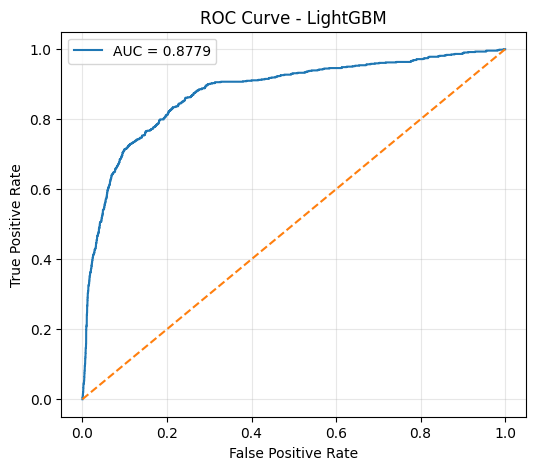

In [340]:
lgbm_fpr, lgbm_tpr, _ = roc_curve(
    y_test,
    lgbm_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    lgbm_fpr,
    lgbm_tpr,
    label=f"AUC = {roc_auc_score(y_test, lgbm_prob):.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - LightGBM")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Precision-Recall Curve

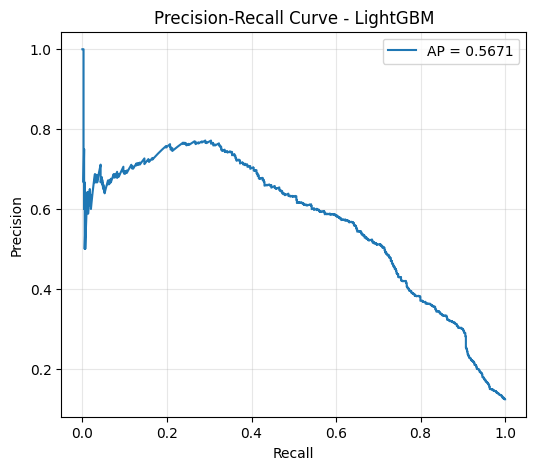

In [341]:
lgbm_precision, lgbm_recall, _ = precision_recall_curve(
    y_test,
    lgbm_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    lgbm_recall,
    lgbm_precision,
    label=f"AP = {average_precision_score(y_test, lgbm_prob):.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - LightGBM")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# 6. Tuned Modeling

## 6.1 Logistic Regression

### Model Training

In [342]:
logreg_pipeline = Pipeline(
    steps=[
        ("smote", SMOTETomek(random_state=42)),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

param_dist = {
    "model__C": np.logspace(-3, 2, 50),
    "model__penalty": ["l1", "l2"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logreg_random_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42
)

logreg_random_search.fit(
    X_train_encoded,
    y_train
)

print(f"Best F1 Score: {logreg_random_search.best_score_:.4f}")

print()

print("Best Parameters:")

print(logreg_random_search.best_params_)

Best F1 Score: 0.4520

Best Parameters:
{'model__penalty': 'l1', 'model__C': np.float64(0.001)}


### Prediction

In [343]:
logreg_tuned_pred = logreg_random_search.predict(
    X_test_encoded
)

logreg_tuned_prob = logreg_random_search.predict_proba(
    X_test_encoded
)[:, 1]

### Classification Report

In [344]:
print(
    classification_report(
        y_test,
        logreg_tuned_pred,
        target_names=["Non-Fraud", "Fraud"],
        digits=4
    )
)

              precision    recall  f1-score   support

   Non-Fraud     0.9150    0.9382    0.9265      5257
       Fraud     0.4672    0.3836    0.4213       743

    accuracy                         0.8695      6000
   macro avg     0.6911    0.6609    0.6739      6000
weighted avg     0.8596    0.8695    0.8639      6000



### Confusion Matrix

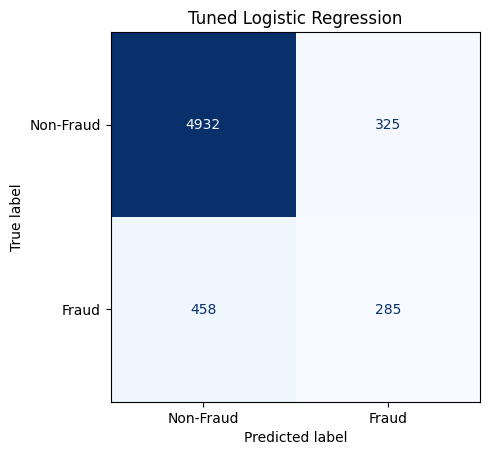

In [345]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logreg_tuned_pred,
    display_labels=["Non-Fraud", "Fraud"],
    cmap="Blues",
    colorbar=False
)

plt.title("Tuned Logistic Regression")

plt.show()

### ROC Curve

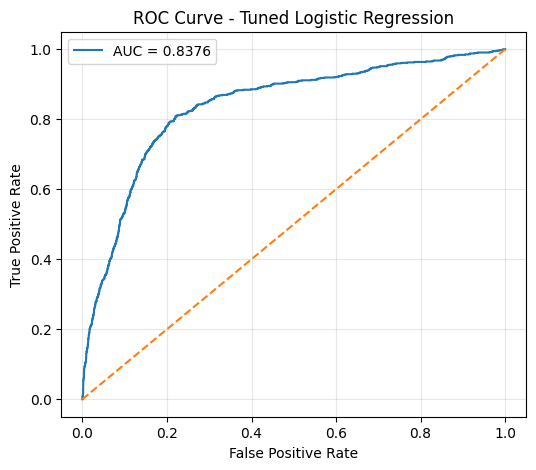

In [346]:
logreg_tuned_fpr, logreg_tuned_tpr, _ = roc_curve(
    y_test,
    logreg_tuned_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    logreg_tuned_fpr,
    logreg_tuned_tpr,
    label=f"AUC = {roc_auc_score(y_test, logreg_tuned_prob):.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Tuned Logistic Regression")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Precision-Recall Curve

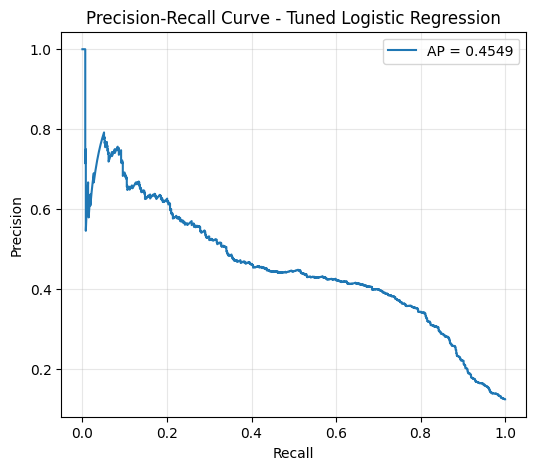

In [347]:
logreg_tuned_precision, logreg_tuned_recall, _ = precision_recall_curve(
    y_test,
    logreg_tuned_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    logreg_tuned_recall,
    logreg_tuned_precision,
    label=f"AP = {average_precision_score(y_test, logreg_tuned_prob):.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Tuned Logistic Regression")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## 6.2 LightGBM

### Model Training

In [348]:
lgbm_pipeline = Pipeline(
    steps=[
        ("smote", SMOTETomek(random_state=42)),
        (
            "model",
            LGBMClassifier(
                random_state=42,
                verbosity=-1
            )
        )
    ]
)

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [-1, 5, 10, 15],
    "model__num_leaves": [15, 31, 63],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42
)

random_search.fit(
    X_train_encoded,
    y_train
)

print(f"Best F1 Score: {random_search.best_score_:.4f}")

print()

print("Best Parameters:")

print(random_search.best_params_)

Best F1 Score: 0.5780

Best Parameters:
{'model__subsample': 0.8, 'model__num_leaves': 63, 'model__n_estimators': 100, 'model__max_depth': 15, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}


### Prediction

In [350]:
lgbm_tuned_pred = random_search.predict(
    X_test_encoded
)

lgbm_tuned_prob = random_search.predict_proba(
    X_test_encoded
)[:, 1]

### Classification Report

In [351]:
print(
    classification_report(
        y_test,
        lgbm_tuned_pred,
        target_names=["Non-Fraud", "Fraud"],
        digits=4
    )
)

              precision    recall  f1-score   support

   Non-Fraud     0.9403    0.9435    0.9419      5257
       Fraud     0.5903    0.5760    0.5831       743

    accuracy                         0.8980      6000
   macro avg     0.7653    0.7598    0.7625      6000
weighted avg     0.8970    0.8980    0.8975      6000



### Confusion Matrix

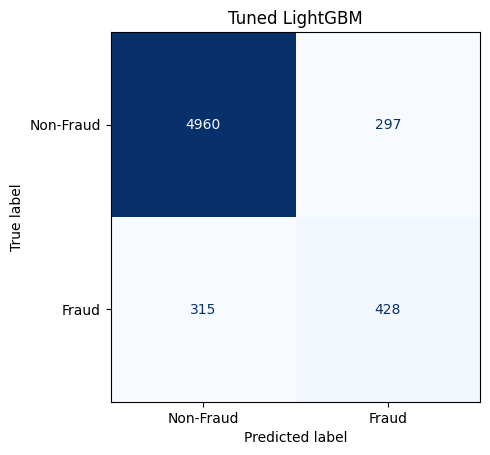

In [352]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lgbm_tuned_pred,
    display_labels=["Non-Fraud", "Fraud"],
    cmap="Blues",
    colorbar=False
)

plt.title("Tuned LightGBM")

plt.show()

### ROC Curve

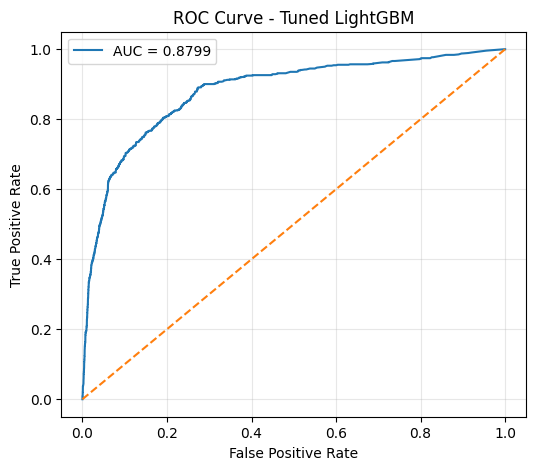

In [353]:
lgbm_tuned_fpr, lgbm_tuned_tpr, _ = roc_curve(
    y_test,
    lgbm_tuned_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    lgbm_tuned_fpr,
    lgbm_tuned_tpr,
    label=f"AUC = {roc_auc_score(y_test, lgbm_tuned_prob):.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Tuned LightGBM")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Precision-Recall Curve

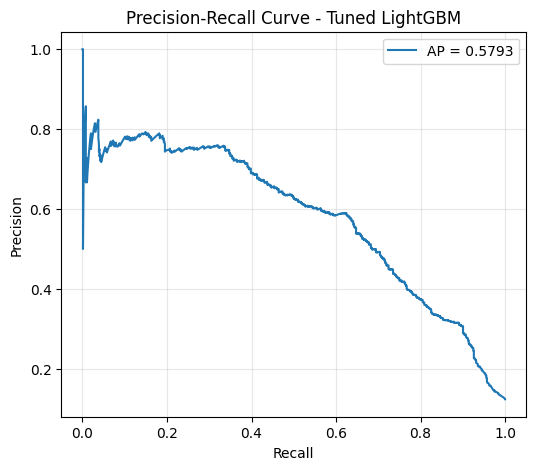

In [354]:
lgbm_tuned_precision, lgbm_tuned_recall, _ = precision_recall_curve(
    y_test,
    lgbm_tuned_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    lgbm_tuned_recall,
    lgbm_tuned_precision,
    label=f"AP = {average_precision_score(y_test, lgbm_tuned_prob):.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Tuned LightGBM")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# 7. Best Model Selection

In [355]:
models = {
    "Logistic Regression": {
        "pred": logreg_pred,
        "prob": logreg_prob
    },
    "LightGBM": {
        "pred": lgbm_pred,
        "prob": lgbm_prob
    },
    "Tuned Logistic Regression": {
        "pred": logreg_tuned_pred,
        "prob": logreg_tuned_prob
    },
    "Tuned LightGBM": {
        "pred": lgbm_tuned_pred,
        "prob": lgbm_tuned_prob
    }
}

comparison = pd.DataFrame(
    [
        {
            "Model": model,
            "Accuracy": accuracy_score(y_test, result["pred"]),
            "Precision": precision_score(
                y_test,
                result["pred"],
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                result["pred"],
                zero_division=0
            ),
            "F1-Score": f1_score(
                y_test,
                result["pred"],
                zero_division=0
            ),
            "ROC AUC": roc_auc_score(
                y_test,
                result["prob"]
            ),
            "Average Precision": average_precision_score(
                y_test,
                result["prob"]
            )
        }
        for model, result in models.items()
    ]
).round(4)

comparison.style.highlight_max(
    subset=comparison.columns[1:],
    color="#d4edda"
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Average Precision
0,Logistic Regression,0.894300,0.670800,0.288000,0.403000,0.856800,0.522100
1,LightGBM,0.902200,0.661200,0.430700,0.521600,0.877900,0.567100
2,Tuned Logistic Regression,0.869500,0.467200,0.383600,0.421300,0.837600,0.454900
3,Tuned LightGBM,0.898000,0.590300,0.576000,0.583100,0.879900,0.579300


In [356]:
selection_metric = "F1-Score"

best_model = comparison.loc[
    comparison[selection_metric].idxmax(),
    "Model"
]

best_result = models[best_model]

best_pred = best_result["pred"]
best_prob = best_result["prob"]

print(f"Selected Model   : {best_model}")
print(f"Selection Metric : {selection_metric}")
print(
    f"Best {selection_metric:<12}: "
    f"{comparison[selection_metric].max():.4f}"
)

Selected Model   : Tuned LightGBM
Selection Metric : F1-Score
Best F1-Score    : 0.5831


# 8. Threshold Optimization

## 8.1 Threshold Comparison

In [357]:
threshold_start = 0.30
threshold_end = 0.70
threshold_step = 0.05

thresholds = np.arange(
    threshold_start,
    threshold_end + threshold_step,
    threshold_step
)

threshold_results = pd.DataFrame(
    [
        {
            "Threshold": threshold,
            "Precision": precision_score(
                y_test,
                (best_prob >= threshold).astype(int),
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                (best_prob >= threshold).astype(int),
                zero_division=0
            ),
            "F1-Score": f1_score(
                y_test,
                (best_prob >= threshold).astype(int),
                zero_division=0
            )
        }
        for threshold in thresholds
    ]
).round(4)

threshold_results.style.highlight_max(
    subset=[selection_metric],
    color="#d4edda"
)

,Threshold,Precision,Recall,F1-Score
0,0.300000,0.359600,0.810200,0.498100
1,0.350000,0.501000,0.683700,0.578300
2,0.400000,0.546000,0.647400,0.592400
3,0.450000,0.584200,0.625800,0.604300
4,0.500000,0.590300,0.576000,0.583100
5,0.550000,0.620300,0.510100,0.559800
6,0.600000,0.655600,0.453600,0.536200
7,0.650000,0.713600,0.389000,0.503500
8,0.700000,0.754700,0.323000,0.452400


## 8.2 Optimal Threshold Selection

In [358]:
best_threshold = threshold_results.loc[
    threshold_results[selection_metric].idxmax()
]

optimal_threshold = best_threshold["Threshold"]

optimal_pred = (
    best_prob >= optimal_threshold
).astype(int)

print(f"Optimal Threshold : {optimal_threshold:.2f}")
print(
    f"Best {selection_metric:<12}: "
    f"{best_threshold[selection_metric]:.4f}"
)

Optimal Threshold : 0.45
Best F1-Score    : 0.6043


# 9. Evaluation with the Optimal Threshold

## 9.1 Performance Comparison

In [359]:
evaluation = pd.DataFrame(
    [
        {
            "Threshold": 0.50,
            "Accuracy": accuracy_score(
                y_test,
                best_pred
            ),
            "Precision": precision_score(
                y_test,
                best_pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                best_pred,
                zero_division=0
            ),
            "F1-Score": f1_score(
                y_test,
                best_pred,
                zero_division=0
            )
        },
        {
            "Threshold": optimal_threshold,
            "Accuracy": accuracy_score(
                y_test,
                optimal_pred
            ),
            "Precision": precision_score(
                y_test,
                optimal_pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                optimal_pred,
                zero_division=0
            ),
            "F1-Score": f1_score(
                y_test,
                optimal_pred,
                zero_division=0
            )
        }
    ]
).round(4)

evaluation.style.highlight_max(
    subset=evaluation.columns[1:],
    color="#d4edda"
)

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.500000,0.898000,0.590300,0.576000,0.583100
1,0.450000,0.898500,0.584200,0.625800,0.604300


# 10. Feature Importance


In [363]:
feature_importance = pd.DataFrame(
    {
        "Feature": X_train_encoded.columns,
        "Importance": (
            random_search
            .best_estimator_
            .named_steps["model"]
            .booster_
            .feature_importance(
                importance_type="gain"
            )
        )
    }
)

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance.head(15)

,Feature,Importance
0,claim_amount,479134.720372
1,police_report_available_YES,349659.467020
2,police_report_available_NO,89668.397938
3,collision_type_Rear Collision,86005.797867
4,collision_type_Unknown,65840.772123
5,incident_type_Vehicle Theft,54446.207330
6,witnesses,44120.761099
7,incident_type_Single Vehicle Collision,41966.948545
8,total_claim_amount,37715.843328
9,collision_type_Side Collision,36113.134542


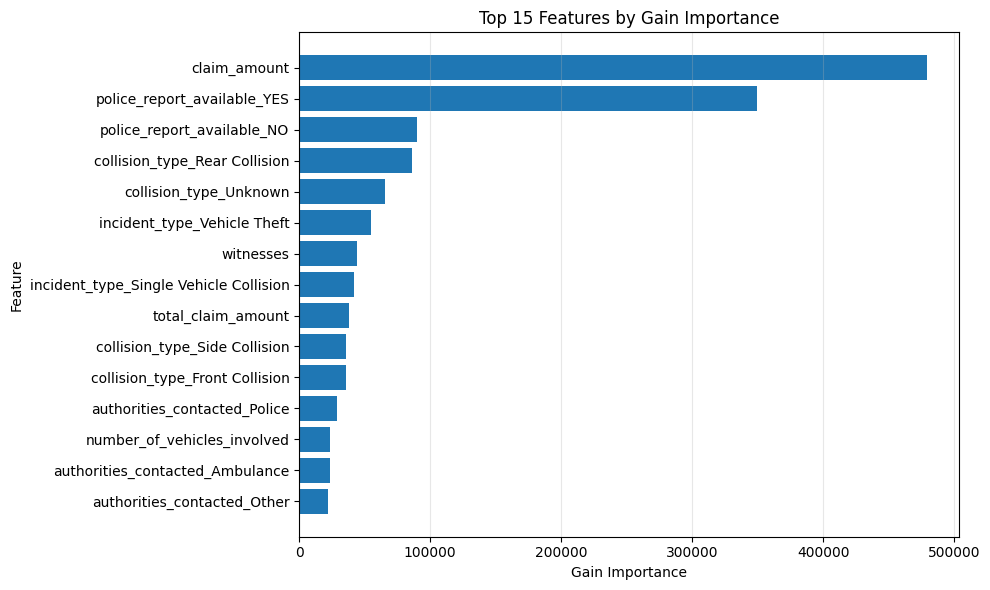

In [364]:
top_n = 15

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"][:top_n][::-1],
    feature_importance["Importance"][:top_n][::-1]
)

plt.xlabel("Gain Importance")

plt.ylabel("Feature")

plt.title(f"Top {top_n} Features by Gain Importance")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()